# 03 — Preparación de Datos para BERT

1. Cargar el dataset aumentado
2. Encoding de etiquetas
3. Split estratificado train / val / test
4. Tokenización con `dccuchile/bert-base-spanish-wwm-cased`
5. Análisis de distribución de tokens (para ajustar `max_length`)
6. Guardar splits procesados

**Prerequisito:** haber ejecutado `01_data_augmentation.ipynb`

In [10]:
import torch
print(torch.__version__, torch.cuda.is_available())

2.6.0+cu124 True


In [ ]:
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer


def _find_repo_root(start: Path) -> Path:
    """Sube desde start hasta encontrar .git o pyproject.toml (raíz del repo)."""
    for p in [start, *start.parents]:
        if (p / '.git').exists() or (p / 'pyproject.toml').exists():
            return p
    return start


ROOT = _find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ["TRANSFORMERS_OFFLINE"] = "1"
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

PIPELINE_DIR = ROOT / 'src/classifier/bert_pipeline'
JSONL_PATH   = PIPELINE_DIR / 'data/dataset_augmented.jsonl'
CSV_FALLBACK = ROOT / 'src/classifier/classifier_dataset_fusionado/datasets/eu_ai_act_flagged_es_limpio.csv'
MODEL_DIR    = PIPELINE_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
LABELS = ['inaceptable', 'alto_riesgo', 'riesgo_limitado', 'riesgo_minimo']
SEED = 42
print('OK')

## 1. Cargar dataset

In [ ]:
if JSONL_PATH.exists():
    records = [json.loads(line) for line in JSONL_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
    df = pd.DataFrame(records).rename(columns={'etiqueta': 'etiqueta_normalizada'})
    print(f'Cargado dataset aumentado: {len(df)} ejemplos')
else:
    df = pd.read_csv(CSV_FALLBACK)[['descripcion', 'etiqueta_normalizada']].dropna()
    df['source'] = 'original'
    print(f'⚠️  Usando CSV original como fallback: {len(df)} ejemplos')

df = df[df['etiqueta_normalizada'].isin(LABELS)].reset_index(drop=True)
print('\nDistribución:')
print(df['etiqueta_normalizada'].value_counts().to_string())

## 2. Encoding de etiquetas

In [13]:
le = LabelEncoder()
le.fit(LABELS)  # orden fijo: inaceptable=0, alto_riesgo=1, riesgo_limitado=2, riesgo_minimo=3
df['label'] = le.transform(df['etiqueta_normalizada'])

print('Mapping etiqueta → id:')
for label, idx in zip(le.classes_, range(len(le.classes_))):
    print(f'  {idx} → {label}')

# Guardar label encoder para inferencia
joblib.dump(le, MODEL_DIR / 'label_encoder.joblib')
print('\nlabel_encoder.joblib guardado.')

Mapping etiqueta → id:
  0 → alto_riesgo
  1 → inaceptable
  2 → riesgo_limitado
  3 → riesgo_minimo

label_encoder.joblib guardado.


## 3. Split estratificado 80 / 10 / 10

Train : 3198 (80.0%)
Val   : 400   (10.0%)
Test  : 400  (10.0%)


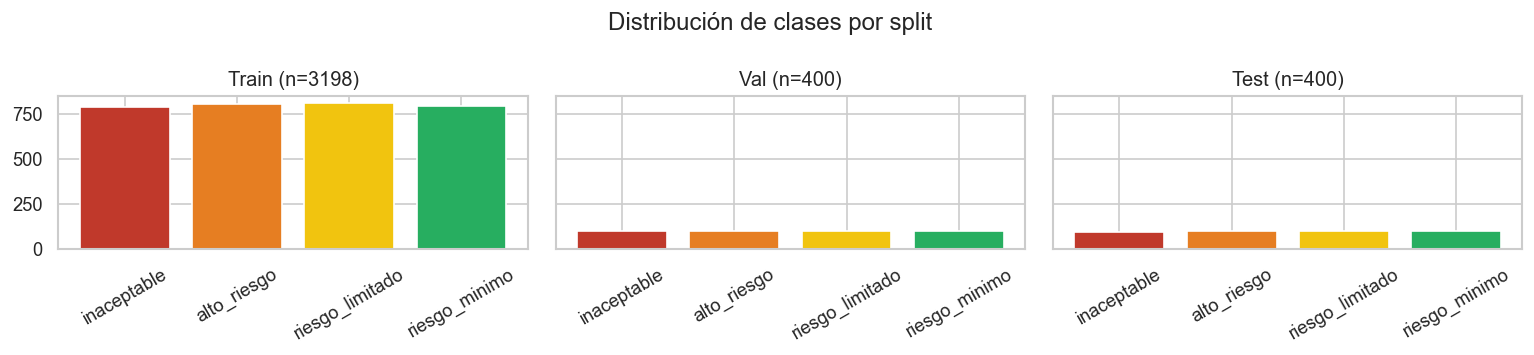

In [14]:
df_train, df_temp = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
df_val, df_test   = train_test_split(df_temp, test_size=0.5, stratify=df_temp['label'], random_state=SEED)

print(f'Train : {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val)}   ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test)}  ({len(df_test)/len(df)*100:.1f}%)')

# Verificar distribución de clases en cada split
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
COLORS = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60']
for ax, (split_df, split_name) in zip(axes, [(df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')]):
    counts = split_df['etiqueta_normalizada'].value_counts().reindex(LABELS, fill_value=0)
    ax.bar(LABELS, counts.values, color=COLORS)
    ax.set_title(f'{split_name} (n={len(split_df)})')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribución de clases por split')
plt.tight_layout()
plt.show()

## 4. Pesos de clase

Usados para penalizar más los errores en clases minoritarias durante el entrenamiento.

In [ ]:
class_weights = compute_class_weight('balanced', classes=np.arange(len(LABELS)), y=df_train['label'].values)

# le.classes_ está en el mismo orden que los ids numéricos (alfabético sklearn)
weight_labels = le.classes_.tolist()

print('Class weights (balanced):')
for label, w in zip(weight_labels, class_weights):
    print(f'  {label:<22} {w:.3f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(weight_labels, class_weights, color=COLORS)
ax.set_ylabel('Weight')
ax.set_title('Class weights (cuanto más alto, más penaliza los errores en esa clase)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 5. Análisis de tokenización

Determinamos si `max_length=512` es suficiente para cubrir la mayoría de los textos.

In [ ]:
print(f'Cargando tokenizer: {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Contar tokens en una muestra (máx 500 para no tardar demasiado)
sample = df['descripcion'].sample(min(500, len(df)), random_state=SEED).tolist()
token_counts = [len(tokenizer.encode(t, truncation=False)) for t in sample]

print('\nEstadísticas de longitud (tokens):')
print(f'  Media    : {np.mean(token_counts):.1f}')
print(f'  Mediana  : {np.median(token_counts):.1f}')
print(f'  P95      : {np.percentile(token_counts, 95):.1f}')
print(f'  Máximo   : {np.max(token_counts)}')
print(f'  > 512    : {sum(c > 512 for c in token_counts)} ({sum(c > 512 for c in token_counts)/len(token_counts)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(token_counts, bins=40, color='steelblue', edgecolor='white')
ax.axvline(512, color='red', linestyle='--', label='max_length=512')
ax.set_xlabel('Nº de tokens')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitud en tokens')
ax.legend()
plt.tight_layout()
plt.show()

pct_largo = (df['descripcion'].str.len() > 512*4).mean() * 100
print(f'\nEjemplos que posiblemente superen 512 tokens: {pct_largo:.1f}%')

## 6. Guardar splits para el notebook de entrenamiento

In [17]:
cols = ['descripcion', 'etiqueta_normalizada', 'label']
joblib.dump(df_train[cols].reset_index(drop=True), MODEL_DIR / 'train_split.joblib')
joblib.dump(df_val[cols].reset_index(drop=True),   MODEL_DIR / 'val_split.joblib')
joblib.dump(df_test[cols].reset_index(drop=True),  MODEL_DIR / 'test_split.joblib')

print('Splits guardados en:', MODEL_DIR)
print('  train_split.joblib :', len(df_train))
print('  val_split.joblib   :', len(df_val))
print('  test_split.joblib  :', len(df_test))
print('\n✓ Listo para el notebook 04_entrenamiento.ipynb')

Splits guardados en: C:\Users\rammu\Documents\Asignaturas Keepcoding\Proyecto final\proyecto-final\src\classifier\bert_pipeline\models
  train_split.joblib : 3198
  val_split.joblib   : 400
  test_split.joblib  : 400

✓ Listo para el notebook 04_entrenamiento.ipynb
